In [1]:
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt
from VSP_Auxiliary import *

ModuleNotFoundError: No module named 'astroquery'

In [4]:
def get_gaia_dr3(coord, radius=2.0, save_path=None): 
    # 输入：坐标对象，搜索半径(角秒)
    # 功能：在线获取并返回Gaia DR3基本数据(astroTable)
    rad = u.Quantity(radius/3600., u.deg)
    Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"  # Reselect Data Release 3, default
    gaiadr3_table = Gaia.load_table('gaiadr3.gaia_source') # 加载Gaia DR3星表
    
    Gaia.ROW_LIMIT = 5  # Ensure the default row limit.
    try:
        j = Gaia.cone_search_async(coord, radius=rad)
        r = j.get_results()
    except:
        try:
            j = Gaia.cone_search_async(coord, radius=rad)
            r = j.get_results() 
        except:
            print('Could not get Gaia DR3 data.')
            r = False
    if r and save_path is not None:
        r.write(save_path, overwrite=True, format='ascii.csv')
        print('GAIA DR3 data has been saved to',save_path)
    return r

# 测试
#coord = SkyCoord(ra=103.154937, dec=+24.606182, unit=(u.deg,u.deg), frame='icrs')
#get_gaia_dr3(coord, radius=2.0, save_path='./Temp/dr3data.csv')

INFO: Query finished. [astroquery.utils.tap.core]
GAIA DR3 data has been saved to ./Temp/dr3data.csv


solution_id,DESIGNATION,SOURCE_ID,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot,dist
,,,,yr,deg,mas,deg,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,,,deg,,,,,,,,deg,deg,deg,deg,,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,log(cm.s**-2),dex,,km / s,km / s,,mag,mag,,,,deg,deg,deg,deg,,,,,,,,,,,,,,,K,K,K,log(cm.s**-2),log(cm.s**-2),log(cm.s**-2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,
int64,object,int64,int64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,int16,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,int16,int16,int16,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,fl

In [5]:
def get_gaia_edr3_distance(coord, radius=2.0, save_path=None): 
    # 输入：坐标对象，搜索半径(角秒)
    # 功能：返回GAIA EDR3距离
    try:
        result = Vizier.query_region(coord, radius=Angle(radius/3600, "deg"), 
                                     catalog='I/352/gedr3dis') # 搜索范围2角秒
    except:
        try:
            result = Vizier.query_region(coord, radius=Angle(radius/3600, "deg"), 
                                         catalog='I/352/gedr3dis')
        except:
            result = []
            print('Could not obtain GAIA EDR3 diatances from Vizier.')

    if result is not None and len(result)>0:
        raICRS = result[0]["RA_ICRS"]
        decICRS = result[0]["DE_ICRS"]
        GAIA_coor = SkyCoord(raICRS.value[0]*u.deg, decICRS.value[0]*u.deg, frame='icrs')
        result[0]['query_ra'] = coord.ra
        result[0]['query_dec'] = coord.dec
        result[0]['dist_deviation(")'] = GAIA_coor.separation(coord).to(u.arcsec)
        r = result[0]
    else:
        r = False
    if r and save_path is not None:
        r.write(save_path, overwrite=True, format='ascii.csv')
        print('GAIA EDR3 distances has been saved to',save_path)
    return r

# 测试
#coord = SkyCoord(ra=103.154937, dec=+24.606182, unit=(u.deg,u.deg), frame='icrs')
#get_gaia_edr3_distance(coord, radius=1.0, save_path='./Temp/edr3dist.csv')

GAIA DR3 data has been saved to ./Temp/edr3dist.csv


Source,RA_ICRS,DE_ICRS,rgeo,b_rgeo,B_rgeo,rpgeo,b_rpgeo,B_rpgeo,Flag,query_ra,query_dec,"dist_deviation("")"
,deg,deg,pc,pc,pc,pc,pc,pc,,deg,deg,arcsec
int64,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64
3381302309033551360,103.15496005010,24.60614166658,1183.92090000,1112.32324000,1258.10144000,1187.70886000,1119.38940000,1283.24561000,10033,103.154937,24.606182,0.1636309331734285


In [6]:
def get_gaia_dr3_epoch(coord, radius=2.0, save_path=None): 
    # 输入：坐标对象，搜索半径(角秒)
    # 功能：返回GAIA DR3时域测光数据(表格)
    try:
        result = Vizier.query_region(coord, radius=Angle(radius/3600, "deg"), catalog='I/355/epphot') # 搜索范围2角秒
        result = result[0]
        result.rename_column('_tab8_5','TimeG')
        result.rename_column('_tab8_6','FG')
        result.rename_column('_tab8_7','e_FG')
        result.rename_column('_tab8_9','Gmag')
        result.rename_column('_tab8_11','TimeBP')
        result.rename_column('_tab8_12','FBP')
        result.rename_column('_tab8_13','e_FBP')
        result.rename_column('_tab8_15','BPmag')
        result.rename_column('_tab8_16','TimeRP')
        result.rename_column('_tab8_17','FRP')
        result.rename_column('_tab8_18','e_FRP')
        result.rename_column('_tab8_20','RPmag')
        # 添加坐标距离
        raICRS = result["RA_ICRS"]
        decICRS = result["DE_ICRS"]
        GAIA_coor = SkyCoord(raICRS.value*u.deg, decICRS.value*u.deg, frame='icrs')
        result['query_ra'] = coord.ra
        result['query_dec'] = coord.dec
        result['dist_deviation(")'] = GAIA_coor.separation(coord).to(u.arcsec)
    except:
        try:
            result = Vizier.query_region(coord, radius=Angle(radius/3600, "deg"), catalog='I/355/epphot')
            result = result[0]
            result.rename_column('_tab8_5','TimeG')
            result.rename_column('_tab8_6','FG')
            result.rename_column('_tab8_7','e_FG')
            result.rename_column('_tab8_9','Gmag')
            result.rename_column('_tab8_11','TimeBP')
            result.rename_column('_tab8_12','FBP')
            result.rename_column('_tab8_13','e_FBP')
            result.rename_column('_tab8_15','BPmag')
            result.rename_column('_tab8_16','TimeRP')
            result.rename_column('_tab8_17','FRP')
            result.rename_column('_tab8_18','e_FRP')
            result.rename_column('_tab8_20','RPmag')
            # 添加坐标距离
            raICRS = result["RA_ICRS"]
            decICRS = result["DE_ICRS"]
            GAIA_coor = SkyCoord(raICRS.value*u.deg, decICRS.value*u.deg, frame='icrs')
            result['query_ra'] = coord.ra
            result['query_dec'] = coord.dec
            result['dist_deviation(")'] = GAIA_coor.separation(coord).to(u.arcsec)
        except:
            result = False
    if result and save_path is not None:
        result.write(save_path, overwrite=True, format='ascii.csv')
        print('GAIA DR3 multiepoch data has been saved to',save_path)
    return result

# 测试
#coord = SkyCoord(ra=103.154937, dec=+24.606182, unit=(u.deg,u.deg), frame='icrs')
#get_gaia_dr3_epoch(coord, radius=2.0, save_path='./Temp/DR3_epoch.csv')

GAIA DR3 multiepoch data has been saved to ./Temp/DR3_epoch.csv


Source,RA_ICRS,DE_ICRS,TransitID,TimeG,FG,e_FG,RFG,Gmag,NG,TimeBP,FBP,e_FBP,RFBP,BPmag,TimeRP,FRP,e_FRP,RFRP,RPmag,noisyFlag,SMuFlag,AF1uFlag,AF2uFlag,AF3uFlag,AF4uFlag,AF5uFlag,AF6uFlag,AF7uFlag,AF8uFlag,AF9uFlag,BPuFlag,RPuFlag,SMrFlag,AF1rFlag,AF2rFlag,AF3rFlag,AF4rFlag,AF5rFlag,AF6rFlag,AF7rFlag,AF8rFlag,AF9rFlag,BPrFlag,RPrFlag,GrVFlag,BPrVFlag,RPrVFlag,query_ra,query_dec,"dist_deviation("")"
,deg,deg,,d,,,,mag,,d,,,,mag,d,,,,mag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,arcsec
int64,float64,float64,int64,float64,float64,float64,float64,float64,uint8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,float64,float64,float64
3381302309033551360,103.15496005010,24.60614166658,17708140097459441,1717.084405,16655.94,28.04483,593.9,15.133444,9,1717.0847,11938.98,69.18332,172.57,15.146124,1717.0848,7288.652,45.46769,160.3,15.091277,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,19595650747622568,1751.222432,14221.08,31.61608,449.81,15.305036,9,1751.2227,9872.355,49.91224,197.79,15.352490,1751.2228,6382.452,43.04795,148.26,15.235427,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,26979722125407705,1884.761431,12937.7,43.86065,294.97,15.407724,9,1884.7617,9138.678,51.10832,178.81,15.436334,1884.7618,5755.132,39.87037,144.35,15.347757,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,26983814447949510,1884.835432,13210.73,26.78784,493.16,15.385050,9,1884.8357,9405.541,55.1115,170.66,15.405083,1884.8358,6017.58,40.38566,149,15.299341,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381302309033551360,103.15496005010,24.60614166658,68460148382004276,2634.912028,11051.17,9.724145,1136.5,15.578846,9,2634.9123,7676.972,43.60117,176.07,15.625567,2634.9124,15796.41,60.59436,260.69,14.251500,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,68464240681996811,2634.986028,11019.68,33.74197,326.59,15.581944,9,2634.9863,7596.521,43.03955,176.5,15.637005,2634.9864,5333.325,37.56306,141.98,15.430400,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,70214863801299380,2666.642018,14502.37,32.74296,442.92,15.283769,8,2666.6423,10132.63,51.57509,196.46,15.324236,2666.6424,6959.04,43.89461,158.54,15.141522,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,103.154937,24.606182,0.1636309331734285


BPRP0,MG0,BP0,RP0
float64,float64,float64,float64
-0.126100000000001,4.377993726401687,4.314593726401686,4.440693726401687


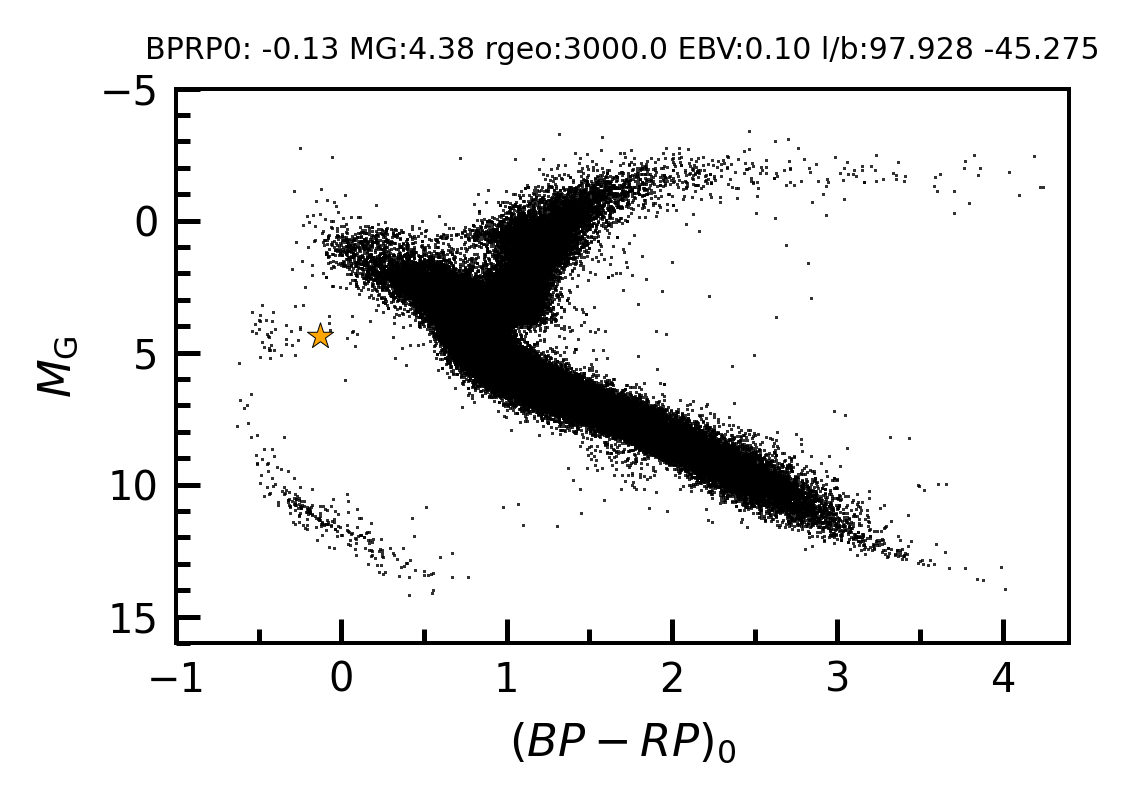

In [3]:
from matplotlib.ticker import MultipleLocator
from astropy.table import Table

#LM_DR10_CMD_Sample = './LIB/LAMOST_DR10_LRS_CMD_Galactic_every50_3kpc_b15_RPlx5.fits' # 原来的
#LM_DR10_CMD_Sample = './LIB/LM_DR10_FOR_CMD_every25.fits'
LM_DR10_CMD_Sample = './LIB/LM_DR10_FOR_CMD_every30.fits' # 新的

col_names = ['BPRP0_green19','MG_rgeo_green19']
try:
    dr10_bprp0, dr10_mg0 = read_fits_cols(LM_DR10_CMD_Sample, col_names)
except:
    print('Error. Could not read "LAMOST_DR10_LRS_CMD_Galactic_every50_3kpc_b15_RPlx5.fits"')

def gaia_dr3_cmd(Gmags, BPmags, RPmags, ebv3ds, dists, ifplot=True, ifshow=False, save_name=None, small=False,  title=True, radec=None, 
                 ebv_replace=True):
    # 输入：Gaia星等，ebv3d(已经归一化到SFD的值)，距离(in pc)，输入可以是数字或数组，若ifplot为True则绘图，若save_name不是None则保存图片到指定位置
    # 功能：绘制GAIA CMD，可选是否展示，是否保存图片，返回(MG0,BPRP0)
    # 将输入的纯数字统一转换成数组
    if isinstance(Gmags, (int, float)):
        Gmags = np.array([Gmags])
    else:
        Gmags = np.array(Gmags)
    if isinstance(BPmags, (int, float)):
        BPmags = np.array([BPmags])
    else:
        BPmags = np.array(BPmags)
    if isinstance(RPmags, (int, float)):
        RPmags = np.array([RPmags])
    else:
        RPmags = np.array(RPmags)
    if isinstance(ebv3ds, (int, float)):
        ebv3ds = np.array([ebv3ds])
    else:
        ebv3ds = np.array(ebv3ds)
    if isinstance(dists, (int, float)):
        dists = np.array([dists])
    else:
        dists = np.array(dists)

    # 计算绝对星等MG0和BPRP0
    # 消光系数(Zhang_2023_ApJS_264_14)(Yuan_2013_MNRAS)
    R_G=2.364
    R_BP=2.998
    R_RP=1.737
    # 消光值
    if ebv_replace: # 如果EBV是nan，
        if True in np.isnan(ebv3ds): # 如果ebv3ds中包含np.nan
            print('* EBV nan values have been replaced by 0.')
        ebv3ds0 = np.nan_to_num(ebv3ds)
        A_g  = ebv3ds0*R_G
        A_bp = ebv3ds0*R_BP
        A_rp = ebv3ds0*R_RP
    else:
        A_g  = ebv3ds*R_G
        A_bp = ebv3ds*R_BP
        A_rp = ebv3ds*R_RP
    # 改正消光
    G0 = Gmags-A_g
    BP0 = BPmags-A_bp
    RP0 = RPmags-A_rp
    # 计算绝对星等
    MG = G0 + 5 - 5*np.log10(dists)
    BP = BP0 + 5 - 5*np.log10(dists)
    RP = RP0 + 5 - 5*np.log10(dists)  
    BPRP0 = BP - RP

    if ifplot:
        #图片大小，LAMOST颜色，标签大小，轴标题大小，x间隔，y间隔，x小刻度，y小刻度，主副刻度长度，星大小，LAMOST形状，LAMOST透明度，LAMOST大小
        paras = [(5.4,3.6),'gray',11.,11.5, 1,2, 0.2,0.5, 5,3, 58,'o',0.4, 1]
        if small:
            paras = [(3.2,2),'k',8.,9., 1,5, 0.5,1, 4.8,2.7, 30,'s',0.8, 0.36] 
        fig,ax = plt.subplots(figsize=paras[0],dpi=360)
        ax.minorticks_on() # 开启副刻度
        plt.scatter(dr10_bprp0, dr10_mg0, 
                    marker=paras[11],s=paras[13],alpha=paras[12],c=paras[1],edgecolors='None',rasterized=True,zorder=0)
        plt.scatter(BPRP0,MG,
                    marker='*',s=paras[10],alpha=0.99,edgecolors='k',facecolor='orange',linewidths=0.2,rasterized=True,zorder=3)
        plt.xticks(np.arange(-1,5,paras[4]),  fontsize=paras[2])
        plt.yticks(np.arange(-5,17,paras[5]), fontsize=paras[2])
        ax.tick_params(axis='both',which='major',direction='in',width=1,length=paras[8])
        ax.tick_params(axis='both',which='minor',direction='in',width=1,length=paras[9])
        ax.xaxis.set_minor_locator(MultipleLocator(paras[6]))
        ax.yaxis.set_minor_locator(MultipleLocator(paras[7]))
        if title and len(MG)==1:
            if radec is not None:
                c = SkyCoord(ra=radec[0], dec=radec[1], unit=(u.deg, u.deg))
                l,b = c.galactic.l.value,c.galactic.b.value
                plt.title(f'BPRP0: {BPRP0[0]:.2f} MG:{MG[0]:.2f} rgeo:{dists[0]:.1f} EBV:{ebv3ds[0]:.2f} l/b:{l:.3f} {b:.3f}',fontsize=paras[3]-3)
            else:
                plt.title(f'BPRP0: {BPRP0[0]:.2f} MG:{MG[0]:.2f} rgeo:{dists[0]:.1f} EBV:{ebv3ds[0]:.2f}',fontsize=paras[3]-3)
        plt.xlim(-1., 4.4)
        plt.ylim(16.,-5.)
        plt.xlabel(r'$(BP-RP)_0$', fontsize=paras[3])
        plt.ylabel(r'$M_{\rm{G}}$',fontsize=paras[3])
        if save_name is not None:
            plt.savefig(save_name, bbox_inches = 'tight', dpi=360)
        if ifshow:
            plt.show()
        plt.close()
        plt.close('all')
         
    tbl = Table()
    tbl['BPRP0'] = BPRP0
    tbl['MG0'] = MG
    tbl['BP0'] = BP
    tbl['RP0'] = RP
    return tbl

# 测试
#gaia_dr3_cmd([17.0], [17.], [17.], [0.1], [3000], save_name='./Temp/cmd_test1.png'),\
#gaia_dr3_cmd([17.,18.], [17.,17.], [17.,17], [0.1,0.1], [3000,3000], save_name='./Temp/cmd_test4.png', small=True)
#gaia_dr3_cmd([17.0], [17.], [17.], [0.1], [3000], save_name='./Temp/cmd_test5.png', small=True, title=True)
#gaia_dr3_cmd([17.0], [17.], [17.], [0.1], [3000], save_name='./Temp/cmd_test7.png', small=True, title=True, radec=(355,+14.1))

In [8]:
def cal_magerr(F,Ferr):
    return np.abs(-2.5/np.log(10)*Ferr/F)

def plot_dr3_lc(data_table, ifshow=False, save_path=None): # I/355/epphot      
    Gtime = data_table["TimeG"] #  Transit averaged G band observing time JD-2455197.5
    GtimeJD = Gtime + 2455197.5
    Gmag = data_table["Gmag"] # Transit averaged G band Vega magnitude
    Gmag.fill_value = np.nan
    Gmag = Gmag.filled()
    FG = data_table["FG"]
    FG.fill_value = np.nan
    FG = FG.filled()
    FGerr = data_table["e_FG"]
    FGerr.fill_value = np.nan
    FGerr = FGerr.filled()
    
    BPtime = data_table["TimeBP"] #  BP CCD transit observing time JD-2455197.5
    BPtimeJD = BPtime + 2455197.5
    BPmag = data_table["BPmag"] # BP band Vega magnitude
    BPmag.fill_value = np.nan
    BPmag = BPmag.filled()
    FBP = data_table["FBP"]
    FBP.fill_value = np.nan
    FBP = FBP.filled()
    FBPerr = data_table["e_FBP"]
    FBPerr.fill_value = np.nan
    FBPerr = FBPerr.filled()
    
    RPtime = data_table["TimeRP"] #  Transit averaged G band observing time JD-2455197.5
    RPtimeJD = RPtime + 2455197.5
    RPmag = data_table["RPmag"] # RP CCD transit observing time JD-2455197.5 
    RPmag.fill_value = np.nan
    RPmag = RPmag.filled()
    FRP = data_table["FRP"]
    FRP.fill_value = np.nan
    FRP = FRP.filled()
    FRPerr = data_table["e_FRP"]
    FRPerr.fill_value = np.nan
    FRPerr = FRPerr.filled()
    
    Gmagerr = cal_magerr(FG,FGerr)
    BPmagerr = cal_magerr(FBP,FBPerr)
    RPmagerr = cal_magerr(FRP,FRPerr)

    f = plt.figure(figsize=(10,3.6), dpi=360)
    bpplot, = plt.plot(BPtimeJD, BPmag, linewidth=0, marker='o', markersize=1.5, color='b', alpha=0.8)
    plt.errorbar(BPtimeJD, BPmag, yerr=BPmagerr, fmt='None', linewidth=0, elinewidth=0.4, capsize=1, color='b', alpha=0.67)
    rpplot, = plt.plot(RPtimeJD, RPmag, linewidth=0, marker='o', markersize=1.5, color='r', alpha=0.8)
    plt.errorbar(RPtimeJD, RPmag, yerr=RPmagerr, fmt='None', linewidth=0, elinewidth=0.4, capsize=1, color='r', alpha=0.67)
    gplot, = plt.plot(GtimeJD, Gmag, linewidth=0, marker='o', markersize=1.5, color='g', alpha=0.8)
    plt.errorbar(GtimeJD, Gmag, yerr=Gmagerr, fmt='None', linewidth=0, elinewidth=0.4, capsize=1, color='g', alpha=0.67)
    ax = plt.gca()
    ax.invert_yaxis()
    plt.xticks(np.arange(1700+2455150,2700+ 2455260,50),[str(int(jj)) if jj%100==0 else '' for jj in np.arange(1700+2455150,2700+ 2455260,50)],\
               fontsize=7.5)
    plt.yticks(np.arange(21.,6.,-0.5),[str(jj) if jj%1==0 else '' for jj in np.arange(21.,6.,-0.5)],\
               fontsize=7.5)
    plt.ylim(20.5,6.5)
    plt.xlabel(r'JD',fontsize=8)
    plt.ylabel(r'mag',fontsize=8)
    plt.title(f'GAIA DR3 light curve', fontsize=8)
    plt.legend([bpplot, rpplot, gplot], ['BPmag', 'RPmag','Gmag'], fontsize=7.5,loc='upper left')
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', dpi=360)
        print('Gaia DR3 lc plot saved to ',save_path)  
    if ifshow:
        plt.show()
    plt.close(f)
    plt.close('all')
    
    data_table['Gmag_err']  = Gmagerr
    data_table['BPmag_err'] = BPmagerr
    data_table['RPmag_err'] = RPmagerr
    cols = data_table.colnames[:20]+data_table.colnames[-3:]+data_table.colnames[-6:-3]
    data_table = data_table[cols]
    return data_table

#coord = SkyCoord(ra=103.154937, dec=+24.606182, unit=(u.deg,u.deg), frame='icrs')
#tbl = get_gaia_dr3_epoch(coord, radius=2.0)
#plot_dr3_lc(tbl, save_path='./Temp/DR3_lc_test.png')

Gaia DR3 lc plot saved to  ./Temp/DR3_lc_test.png


Source,RA_ICRS,DE_ICRS,TransitID,TimeG,FG,e_FG,RFG,Gmag,NG,TimeBP,FBP,e_FBP,RFBP,BPmag,TimeRP,FRP,e_FRP,RFRP,RPmag,Gmag_err,BPmag_err,RPmag_err,query_ra,query_dec,"dist_deviation("")"
,deg,deg,,d,,,,mag,,d,,,,mag,d,,,,mag,,,,deg,deg,arcsec
int64,float64,float64,int64,float64,float64,float64,float64,float64,uint8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3381302309033551360,103.15496005010,24.60614166658,17708140097459441,1717.084405,16655.94,28.04483,593.9,15.133444,9,1717.0847,11938.98,69.18332,172.57,15.146124,1717.0848,7288.652,45.46769,160.3,15.091277,0.001828134,0.006291564,0.006772984,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,19595650747622568,1751.222432,14221.08,31.61608,449.81,15.305036,9,1751.2227,9872.355,49.91224,197.79,15.352490,1751.2228,6382.452,43.04795,148.26,15.235427,0.002413793,0.00548922,0.007323003,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,26979722125407705,1884.761431,12937.7,43.86065,294.97,15.407724,9,1884.7617,9138.678,51.10832,178.81,15.436334,1884.7618,5755.132,39.87037,144.35,15.347757,0.0036808,0.006072011,0.007521756,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,26983814447949510,1884.835432,13210.73,26.78784,493.16,15.385050,9,1884.8357,9405.541,55.1115,170.66,15.405083,1884.8358,6017.58,40.38566,149,15.299341,0.002201584,0.00636184,0.007286679,103.154937,24.606182,0.1636309331734285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381302309033551360,103.15496005010,24.60614166658,68460148382004276,2634.912028,11051.17,9.724145,1136.5,15.578846,9,2634.9123,7676.972,43.60117,176.07,15.625567,2634.9124,15796.41,60.59436,260.69,14.251500,0.0009553605,0.006166411,0.004164838,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,68464240681996811,2634.986028,11019.68,33.74197,326.59,15.581944,9,2634.9863,7596.521,43.03955,176.5,15.637005,2634.9864,5333.325,37.56306,141.98,15.430400,0.003324496,0.006151446,0.007646931,103.154937,24.606182,0.1636309331734285
3381302309033551360,103.15496005010,24.60614166658,70214863801299380,2666.642018,14502.37,32.74296,442.92,15.283769,8,2666.6423,10132.63,51.57509,196.46,15.324236,2666.6424,6959.04,43.89461,158.54,15.141522,0.002451337,0.005526396,0.006848354,103.154937,24.606182,0.1636309331734285


In [ ]:
# GAIAXP